First tutorial: regression using NumPyro

Source: https://github.com/dfm-io/post--intro-to-numpyro/blob/main/post.ipynb

First, we create a dataset with outliers. The linear model has a slope of 1 and an offset of 0. The probability of outliers is 80%.

In [34]:
import numpy as np
import matplotlib.pyplot as plt

import arviz as az
import corner

import jax
import jax.numpy as jnp

import numpyro
from numpyro import distributions as dist, infer

from astropy.io import fits

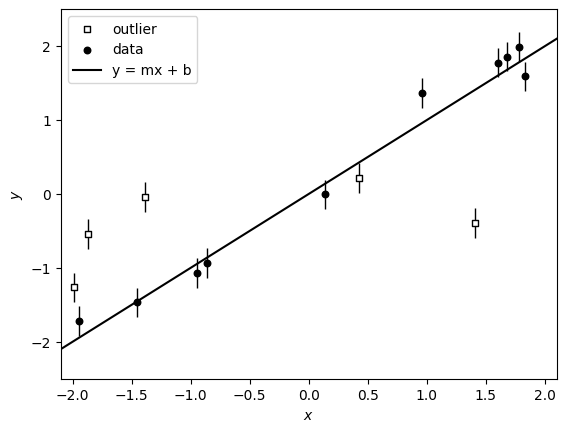

In [ ]:
# Outlier probability
true_frac = 0.8

# Linear model's slope and intercept
true_params = [1.0, 0.0]

# Outliers are drawn from a Gaussian with mean 0 and variance 1
true_outliers = [0.0, 1.0]

# Generate the fake data
np.random.seed(12)
x = np.sort(np.random.uniform(-2, 2, 15))
yerr = 0.2 * np.ones_like(x)
y = true_params[0] * x + true_params[1] + yerr * np.random.randn(len(x))

# Replace some data with outliers
m_bkg = np.random.rand(len(x)) > true_frac
y[m_bkg] = true_outliers[0] + np.sqrt(true_outliers[1] + yerr[m_bkg]**2) * np.random.randn(sum(m_bkg))

# Save the "true" line (this is basically y = mx + b)
x0 = np.linspace(-2.1, 2.1, 200)
y0 = np.dot(np.vander(x0, 2), true_params)

def plot_data():
    plt.errorbar(x, y, yerr=yerr, fmt=",k", ms=0, capsize=0, lw=1, zorder=999)
    plt.scatter(x[m_bkg], y[m_bkg], marker="s", s=22, c="w", edgecolor="k", zorder=1000, label='outlier')
    plt.scatter(
        x[~m_bkg], y[~m_bkg], marker="o", s=22, c="k", zorder=1000, label="data"
    )
    plt.plot(x0, y0, color="k", lw=1.5, label='y = mx + b')
    plt.legend()
    plt.xlabel("$x$")
    plt.ylabel("$y$")
    plt.ylim(-2.5, 2.5)
    plt.xlim(-2.1, 2.1)


plot_data()

# Simple Linear Model

We will parameterise our model using $\theta=\arctan m$, and $b_\perp = b\cos\theta$. 

In NumPyro, probabilistic models are built using Python function that takes in the dataset as input. Inside the function, we define the prior using NumPyro's `numpyro.sample`, and specifying the distribution using `numpyro.distributions`. Everything must be done using `jax.numpy` instead of `numpy`. At the end of the function, the sampling distribution of the data (i.e. the likelihood function) is also defined using `numpyro.sample`.

We first start with a simple linear model that does not account for the outliers.

In [ ]:
numpyro.set_host_device_count(2)

def linear_model(x, yerr, y=None):
    
    # The parameters that we are fitting (must be defined explicitly)
    # Priors are also defined here
    theta = numpyro.sample('theta', dist.Uniform(-0.5 * jnp.pi, 0.5 * jnp.pi))
    b_perp = numpyro.sample('b_perp', dist.Normal(0, 1))

    # Transformed parameters and other things can also be tracked using deterministic
    m = numpyro.deterministic('m', jnp.tan(theta))
    b = numpyro.deterministic('b', b_perp / jnp.cos(theta))

    # Define the likelihood here. Usually done using numpyro.plate to indicate that the data are independent
    # 'plate` -> "this structure is repeated N times (number of independent data)"
    with numpyro.plate('data', len(x)):
        y_model = m * x + b
        numpyro.sample('y', dist.Normal(y_model, yerr), obs=y)

/Users/mrafifrbbn/Documents/phd_projects/project_1/numpyro-tutorial/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Use MCMC to sample the posterior

In [3]:
sampler = infer.MCMC(
    infer.NUTS(linear_model),
    num_warmup=2000,
    num_samples=2000,
    num_chains=2,
    progress_bar=True
)

%time sampler.run(jax.random.PRNGKey(0), x, yerr, y=y)

Compiling.. :   0%|          | 0/4000 [00:00<?, ?it/s]

CPU times: user 1.38 s, sys: 102 ms, total: 1.48 s
Wall time: 1.7 s


Running chain 0:   0%|          | 0/4000 [00:00<?, ?it/s]

Running chain 0: 100%|██████████| 4000/4000 [00:00<00:00, 5283.78it/s]


Check the Gelman-Rubin convergence statistic (r_hat) and the effective sample size (ess_bulk) using `arviz`.

In [ ]:
inf_data = az.from_numpyro(sampler)
az.summary(inf_data)

/Users/mrafifrbbn/Documents/phd_projects/project_1/numpyro-tutorial/.venv/lib/python3.10/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
b,0.122,0.051,0.024,0.214,0.001,0.001,2899.0,2198.0,1.0
b_perp,0.097,0.040,0.020,0.170,0.001,0.001,2931.0,1979.0,1.0
m,0.758,0.035,0.691,0.826,0.001,0.001,3085.0,2404.0,1.0
theta,0.648,0.023,0.605,0.691,0.000,0.000,3085.0,2404.0,1.0


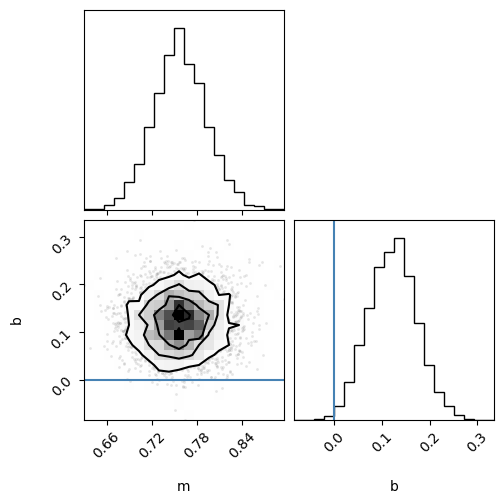

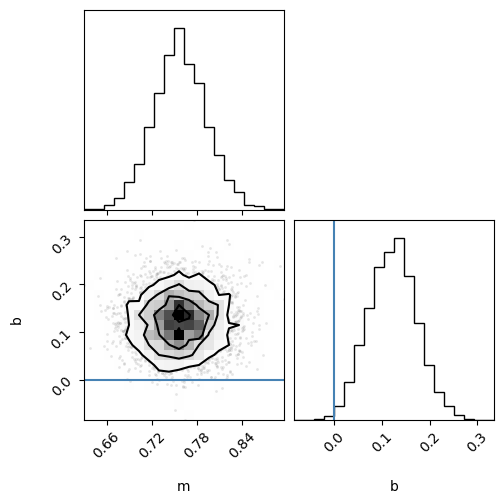

In [ ]:
# Create corner plot
corner.corner(inf_data, var_names=["m", "b"], truths=true_params)

Notice that `y` is given as a keyword argument instead of a positional argument. This is because we can reuse the same model for predictive checks using `numpyro.infer.Predictive`, and then compare with our observed data.

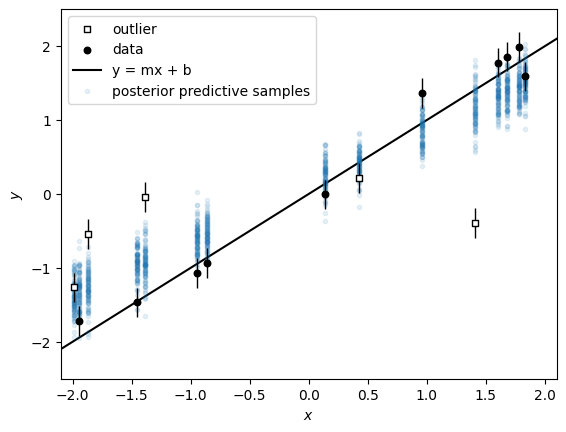

In [6]:
# Generate some simulated data (don't pass y)
post_pred_samples = infer.Predictive(linear_model, sampler.get_samples())(jax.random.PRNGKey(1), x, yerr)
post_pred_y = post_pred_samples['y']

plot_data()
label = "posterior predictive samples"
for n in np.random.default_rng(0).integers(len(post_pred_y), size=100):
    plt.plot(x, post_pred_y[n], ".", color="C0", alpha=0.1, label=label)
    # plt.scatter(x, np.mean(post_pred_y, axis=0)[n], color="r", marker='X', alpha=0.5)
    label = None
plt.legend()

# Accounting for outliers using a mixture model

We'll use the same mixture model as in the `mixture-models.ipynb` notebook. In summary, the above is our "foreground" model, and the "background" for outliers is a Gaussian with a floating mean and standard deviation. Besides $\theta$ and $b_\perp$, we will also fit for the mean and standard deviation of the background model, and the mixture weight $Q$.

NumPyro doesn't include a mixture `Distribution`. There is `MixtureSameFamily` in NumPyro, but it won't work in the next example. Instead, we can make a custom `MixtureGeneral` distribution from dfm's `numpyro-ext` library. Install it with:

`pip install git+https://github.com/dfm/numpyro-ext.git@8a777010e2b4eb135493cf984b8a9a40e2d99a90#egg=numpyro-ext`

In [69]:
! pip install git+https://github.com/dfm/numpyro-ext.git@8a777010e2b4eb135493cf984b8a9a40e2d99a90#egg=numpyro-ext

/opt/homebrew/Cellar/python@3.13/3.13.2/Frameworks/Python.framework/Versions/3.13/lib/python3.13/pty.py:95: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


  Cloning https://github.com/dfm/numpyro-ext.git (to revision 8a777010e2b4eb135493cf984b8a9a40e2d99a90) to /private/var/folders/50/_r7c0z0x3bl4zx6npn1b1x480000gn/T/pip-install-ma8ccjt6/numpyro-ext_8a4ac2fe36d848b98a0782c375e4014a
  Running command git clone --filter=blob:none --quiet https://github.com/dfm/numpyro-ext.git /private/var/folders/50/_r7c0z0x3bl4zx6npn1b1x480000gn/T/pip-install-ma8ccjt6/numpyro-ext_8a4ac2fe36d848b98a0782c375e4014a
  Running command git rev-parse -q --verify 'sha^8a777010e2b4eb135493cf984b8a9a40e2d99a90'
  Running command git fetch -q https://github.com/dfm/numpyro-ext.git 8a777010e2b4eb135493cf984b8a9a40e2d99a90
  Running command git checkout -q 8a777010e2b4eb135493cf984b8a9a40e2d99a90
  Resolved https://github.com/dfm/numpyro-ext.git to commit 8a777010e2b4eb135493cf984b8a9a40e2d99a90
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for numpyro-ext: filenam

In [ ]:
# from numpyro_ext.distributions import MixtureGeneral
from numpyro.distributions import MixtureSameFamily

def linear_mixture_model(x, yerr, y=None):
    # Foreground model: the same as before, parameterised with theta and b_perp.
    # We don't wrap it inside a plate because we will use it in the mixture distribution
    theta = numpyro.sample('theta', dist.Uniform(-0.5 * jnp.pi, 0.5 * jnp.pi))
    b_perp = numpyro.sample('b_perp', dist.Normal(0.0, 1.0))
    m = numpyro.deterministic('m', jnp.tan(theta))
    b = numpyro.deterministic('b', b_perp / jnp.cos(theta))
    fg_dist = dist.Normal(m * x + b, yerr)

    # Background distribution: model the outliers as Gaussian. Fit the mean and standard deviation.
    bg_mean = numpyro.sample('bg_mean', dist.Normal(0.0, 1.0))
    bg_sigma = numpyro.sample('bg_sigma', dist.HalfNormal(3.0))
    bg_dist = dist.Normal(bg_mean, jnp.sqrt(bg_sigma**2 + yerr**2))

    # Use a `Categorical` distribution to define the outlier probability.
    # Fit for the parameter `Q`, the probability that any individual point is a member
    # of the foregroun model. So the "prior" outlier probability is 1 - Q.
    Q = numpyro.sample('Q', dist.Uniform(0.0, 1.0))
    mix = dist.Categorical(probs=jnp.array([Q, 1.0 - Q]))

    # Wrap everything with `plate` (optional)
    with numpyro.plate('data', len(x)):

        # Stack the mean and sigmas for each Gaussian
        locs = jnp.stack([
            m * x + b,
            jnp.full_like(x, bg_mean)
        ], axis=-1)

        scales = jnp.stack([
            yerr,
            jnp.sqrt(yerr**2 + bg_sigma**2)
        ], axis=-1)

        # Arrange the component distribution
        comp_dist = dist.Normal(locs, scales)

        numpyro.sample('obs', MixtureSameFamily(mix, comp_dist), obs=y)

# Run the MCMC
sampler = infer.MCMC(
    infer.NUTS(linear_mixture_model),
    num_chains=2,
    num_warmup=2000,
    num_samples=2000,
    progress_bar=True
)
%time sampler.run(jax.random.PRNGKey(3), x, yerr, y=y)

Compiling.. :   0%|          | 0/4000 [00:00<?, ?it/s]

CPU times: user 2.15 s, sys: 100 ms, total: 2.25 s
Wall time: 1.31 s


Running chain 0:   0%|          | 0/4000 [00:01<?, ?it/s]

Running chain 0: 100%|██████████| 4000/4000 [00:01<00:00, 2547.49it/s]


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Q,0.667,0.126,0.440,0.895,0.002,0.002,3264.0,2537.0,1.0
b,0.054,0.076,-0.091,0.193,0.001,0.001,2985.0,2476.0,1.0
b_perp,0.039,0.054,-0.061,0.142,0.001,0.001,2915.0,2506.0,1.0
bg_mean,-0.409,0.406,-1.139,0.393,0.009,0.010,2558.0,2018.0,1.0
bg_sigma,0.783,0.541,0.006,1.745,0.011,0.015,1615.0,1029.0,1.0
m,1.006,0.056,0.901,1.113,0.001,0.001,2930.0,2288.0,1.0
theta,0.787,0.028,0.734,0.839,0.001,0.000,2930.0,2288.0,1.0


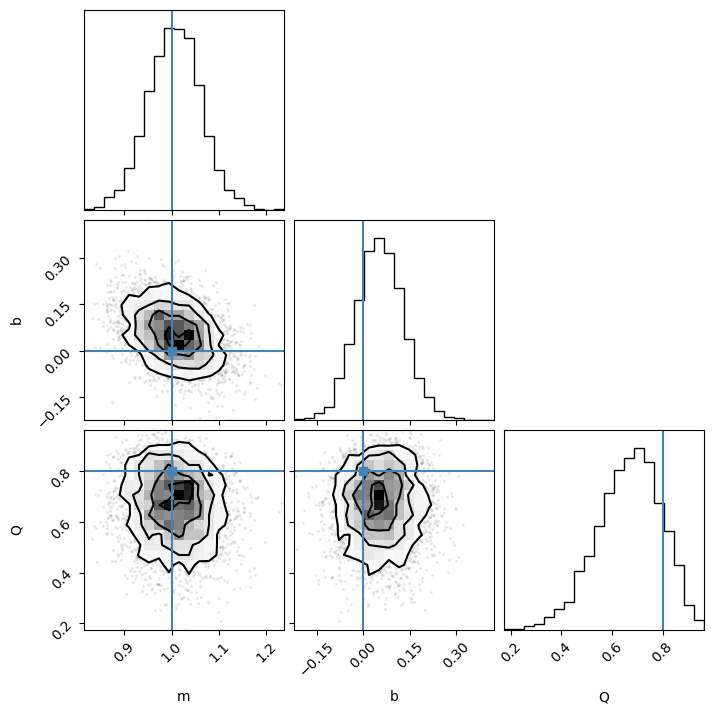

In [97]:
# Check the convergence and corner plot
inf_data = az.from_numpyro(sampler)
corner.corner(
    inf_data,
    var_names=["m", "b", "Q"],
    truths={
        "m": true_params[0],
        "b": true_params[1],
        "Q": true_frac,
    },
)
az.summary(inf_data)

We can also identify which points are outliers.

In [ ]:
def linear_mixture_member_prob_model(x, yerr, y=None):
    # Most are similar to the above model
    theta = numpyro.sample('theta', dist.Uniform(-0.5 * jnp.pi, 0.5 * jnp.pi))
    b_perp = numpyro.sample('b_perp', dist.Normal(0.0, 1.0))
    m = numpyro.deterministic('m', jnp.tan(theta))
    b = numpyro.deterministic('b', b_perp / jnp.cos(theta))
    bg_mean = numpyro.sample('bg_mean', dist.Normal(0.0, 1.0))
    bg_sigma = numpyro.sample('bg_sigma', dist.HalfNormal(3.0))
    Q = numpyro.sample('Q', dist.Uniform(0.0, 1.0))
    mix = dist.Categorical(probs=jnp.array([Q, 1.0 - Q]))
    locs = jnp.stack([
        m * x + b,
        jnp.full_like(x, bg_mean)
    ], axis=-1)

    scales = jnp.stack([
        yerr,
        jnp.sqrt(yerr**2 + bg_sigma**2)
    ], axis=-1)
    comp_dist = dist.Normal(locs, scales)
    mixture = MixtureSameFamily(mix, comp_dist)

    with numpyro.plate('data', len(x)):
        y_ = numpyro.sample('obs', mixture, obs=y)

        # Track the membership probability of each sample
        log_probs = mixture.component_log_probs(y_)
        numpyro.deterministic(
            'p', log_probs - jax.nn.logsumexp(log_probs, axis=-1, keepdims=True)
        )

sampler = infer.MCMC(
    infer.NUTS(linear_mixture_member_prob_model),
    num_warmup=2000,
    num_samples=2000,
    num_chains=2,
    progress_bar=True
)

sampler.run(jax.random.PRNGKey(3), x, yerr, y=y)

Running chain 0:   0%|          | 0/4000 [00:01<?, ?it/s]

Running chain 1: 100%|██████████| 4000/4000 [00:01<00:00, 2982.66it/s] 


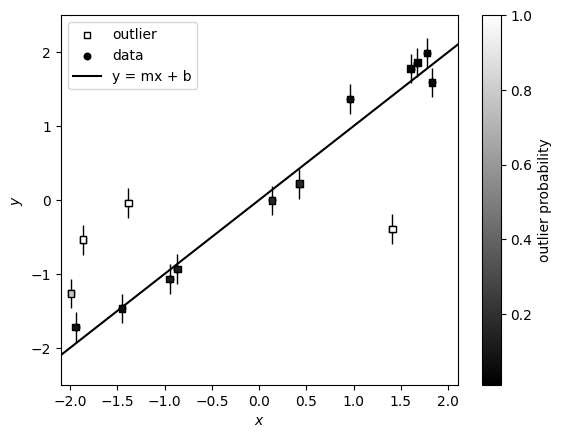

In [ ]:
p_fg = jnp.mean(jnp.exp(sampler.get_samples()["p"][..., 0]), axis=0)
plot_data()
plt.scatter(x, y, marker="s", s=22, c=1 - p_fg, edgecolor="k", zorder=1000, cmap="gray")
plt.colorbar(label="outlier probability")

# Measuring distances using Gaia parallaxes

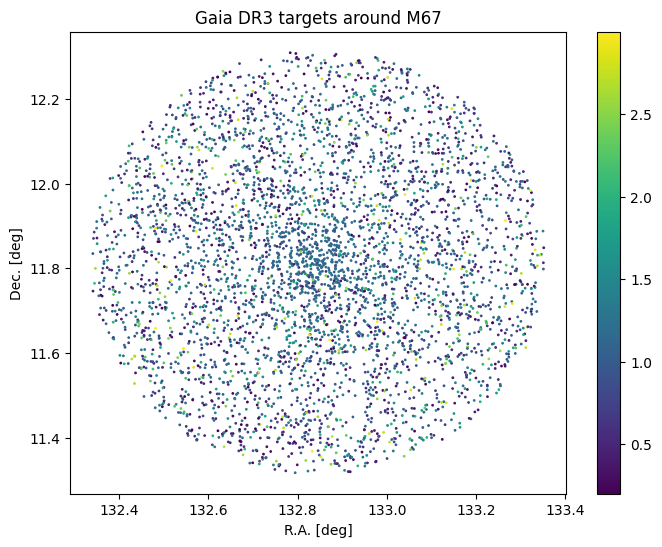

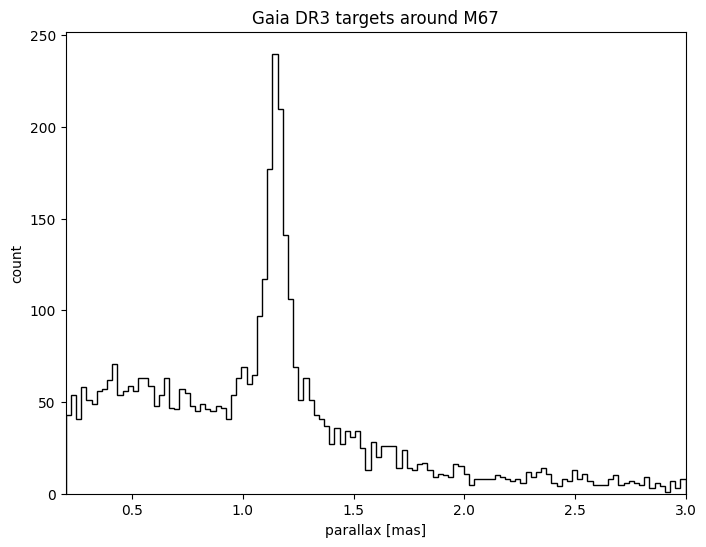

In [15]:
from astropy.io import fits

with fits.open("../data/m67.fits.gz") as f:
    data = f[1].data

mask = np.isfinite(data['parallax'])
mask &= np.isfinite(data['parallax_error'])
mask &= data['parallax'] > 0.2
mask &= data['parallax'] < 3.0
data = data[mask]

plt.figure(figsize=(8, 6))
s = plt.scatter(data['ra'], data['dec'], c=data['parallax'], s=1)
cbar = plt.colorbar(s)
plt.xlabel("R.A. [deg]")
plt.ylabel("Dec. [deg]")
plt.title("Gaia DR3 targets around M67")

plt.figure(figsize=(8, 6))
plt.hist(data["parallax"], 120, histtype="step", color="k")
plt.xlabel("parallax [mas]")
plt.ylabel("count")
plt.title("Gaia DR3 targets around M67")
plt.xlim(0.2, 3.0);

First, we need to estimate the expected parallax zero point offset for all of our targets. We will use `gaiadr3-zeropoint` package.

In [ ]:
import warnings
from zero_point import zpt

zpt.load_tables()
with warnings.catch_warnings():
    warnings.filterwarnings("ignore")
    plx_zp = zpt.get_zpt(
        data["phot_g_mean_mag"],
        data["nu_eff_used_in_astrometry"],
        data["pseudocolour"],
        data["ecl_lat"],
        data["astrometric_params_solved"],
    )
plx_zp[~np.isfinite(plx_zp)] = 0.0

First, we do a warmup by measuring the distance to a star. The prior we choose is in the form (Bailer-Jones 2015):
$$p(r) = \frac{r^2}{2L^3} e^{-r/L}$$
where $L$ is a scale parameter than depends on the sky position (and possibly other parameters) of the target.

This distribution is a chi-squared distribution with 6 degrees of freedom. If $u \sim \chi^2(k=6)$, then $r = u \times L/2$ is distributed as the prior above. NumPyro already has a `Chi2` distribution. We can then apply `TransformedDistribution` and `AffineTransform` (for linear transformation) to the template distribution.

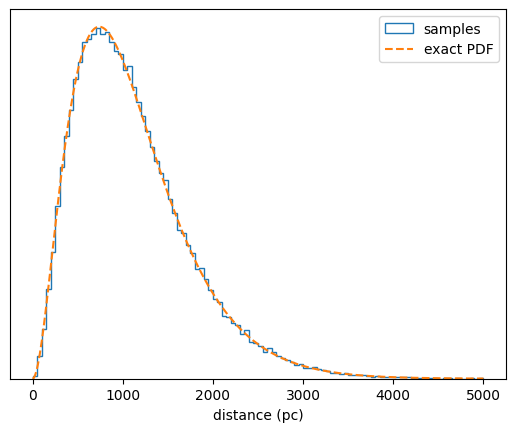

In [19]:
L = 370.0 # Set arbitrarily
prior = dist.TransformedDistribution(
    dist.Chi2(6),
    dist.transforms.AffineTransform(0.0, 0.5 * L),
)
r = prior.sample(jax.random.PRNGKey(0), sample_shape=(100000,))

# Plot histogram of the sample and compare with the prior
x = np.linspace(0, 5000, 500)
plt.hist(r, 100, range=(0, 5000), density=True, histtype='step', label='samples')
plt.plot(x, 0.5 * x**2 * np.exp(-x / L) / L**3, '--', label="exact PDF")
plt.xlabel("distance (pc)")
plt.yticks([])
plt.legend()

Next, we define a model to fit the distance to a single star.

In [29]:
def gaia_single_model(plx_err, plx=None, plx_zp=0.0, L=L):
    normed = numpyro.sample('normed', dist.Chi2(6)) # Could have used AffineTransform directly here
    distance = numpyro.deterministic('r', 0.5 * L * normed) # Calculate r = u * L/2
    numpyro.sample('plx', dist.Normal(1000.0 / distance + plx_zp, plx_err), obs=plx)

In practice, $L$ and $ZP$ can also be inferred from the data.

First, let's look at the prior predictive distribution.

Text(0.5, 0.98, 'prior predictive distribution')

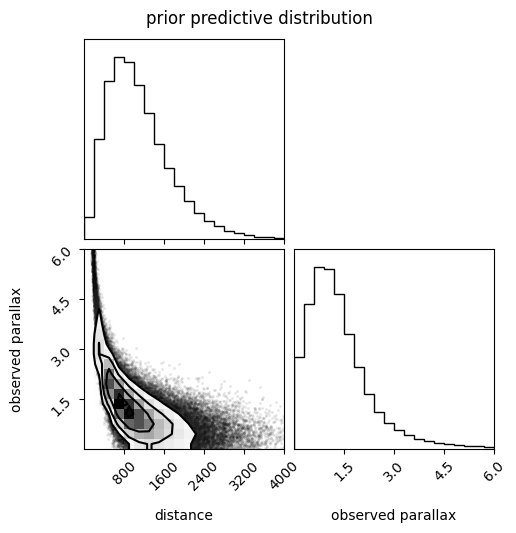

In [35]:
prior_samples = infer.Predictive(gaia_single_model, num_samples=100_000)(
    jax.random.PRNGKey(4), 0.5
)
prior_samples = az.from_dict(prior_samples, num_chains=1)

fig = corner.corner(
    prior_samples,
    var_names=["r", "plx"],
    labels=["distance", "observed parallax"],
    range=[(0, 4000), (0, 6)],
)
fig.suptitle("prior predictive distribution")

Try to fit the distance for one of the targets with low SNR. Since this is 1D, we actually don't need MCMC.

/var/folders/50/_r7c0z0x3bl4zx6npn1b1x480000gn/T/ipykernel_65764/1267853176.py:5: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  sampler = infer.MCMC(
sample: 100%|██████████| 6000/6000 [00:00<00:00, 7836.55it/s, 3 steps of size 1.03e+00. acc. prob=0.92]


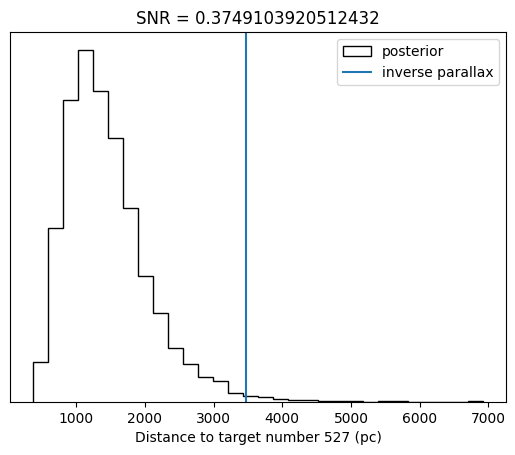

In [50]:
snr = data['parallax'] / data['parallax_error']
single_ind = np.argsort(snr)[50]
plx = data[single_ind]['parallax']
plx_err = data[single_ind]['parallax_error']
sampler = infer.MCMC(
    infer.NUTS(gaia_single_model),
    num_warmup=2000,
    num_samples=4000,
    num_chains=2
)
sampler.run(jax.random.PRNGKey(0), plx_err, plx=plx, plx_zp=plx_zp[single_ind])

samples_single = sampler.get_samples()
plt.hist(samples_single['r'], 30, histtype='step', color='k', label='posterior')
plt.axvline(1000.0 / plx, label='inverse parallax')
plt.xlabel(f'Distance to target number {single_ind} (pc)')
plt.title(f'SNR = {snr[single_ind]}')
plt.legend()
plt.yticks([])
plt.show()

Because the SNR is low, the inferred distance is incosistent with the value computed by inverting the parallax as a distance estimator.

## Inferring distance to M67 using a hierarchical model for parallax

We will build a joint (hierarchical) model for all 4300 targets in the sample to simultaneously fit for:
1. The individual distances to each target $r_n$;
2. The fraction of targets that are cluster members $Q$ (based only on parallax);
3. The background length scale of the background distribution $L$; and
4. The distance $D$ and width $\sigma$ (in log-distance) of M67.

We are modeling the cluster as a Gaussian in log distance, and the background using the Bailer-Jones distribution with the length scale as a free parameter. This model has 4304 parameters (4 population parameters and one distance for each target).

In [ ]:
def gaia_cluster_model(plx_err, plx=None, plx_zp=0.0):
    # Priors on the population parameters. Use Gaussian priors in log
    # because these parameters must be positive. Flat priors are fine, but
    # usually better performance using a prior with some curvature.
    log_L = numpyro.sample('log_L', dist.Normal(np.log(370.0), 2.0))
    log_D = numpyro.sample('log_D', dist.Normal(np.log(920.0), 2.0))
    log_sigma = numpyro.sample('log_sigma', dist.Normal(0.0, 2.0))
    Q = numpyro.sample('Q', dist.Uniform(0.0, 1.0))

    # Track some reparameterised values for plotting
    L = numpyro.deterministic('L', jnp.exp(log_L))
    D = numpyro.deterministic('D', jnp.exp(log_D))

    # Also track the approximate size of the cluster in linear space
    approx_size = numpyro.deterministic('approx_size', jnp.exp(log_sigma + log_D))

    with numpyro.plate('stars', len(plx_err)):
        